In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"supply_chain_data.csv")
df

,Product_type,SKU,Price,Availability,Number_of_ products_sold,Revenue_generated,Customer_demographics,Stock_levels,Lead_times,Order_quantities,...,Location,Lead_time,Production_volumes,Manufacturing_lead_time,Manufacturing_costs,Inspection_results,Defect_rates,Transportation_modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [15]:
df.head()
df.tail()
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Product_type              100 non-null    object 
 1   SKU                       100 non-null    object 
 2   Price                     100 non-null    float64
 3   Availability              100 non-null    int64  
 4   Number_of_ products_sold  100 non-null    int64  
 5   Revenue_generated         100 non-null    float64
 6   Customer_demographics     100 non-null    object 
 7   Stock_levels              100 non-null    int64  
 8   Lead_times                100 non-null    int64  
 9   Order_quantities          100 non-null    int64  
 10  Shipping_times            100 non-null    int64  
 11  Shipping_carriers         100 non-null    object 
 12  Shipping_costs            100 non-null    float64
 13  Supplier_name             100 non-null    object 
 14  Location   

In [18]:
df.isnull().sum()
df.drop_duplicates()

,Product_type,SKU,Price,Availability,Number_of_ products_sold,Revenue_generated,Customer_demographics,Stock_levels,Lead_times,Order_quantities,...,Location,Lead_time,Production_volumes,Manufacturing_lead_time,Manufacturing_costs,Inspection_results,Defect_rates,Transportation_modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


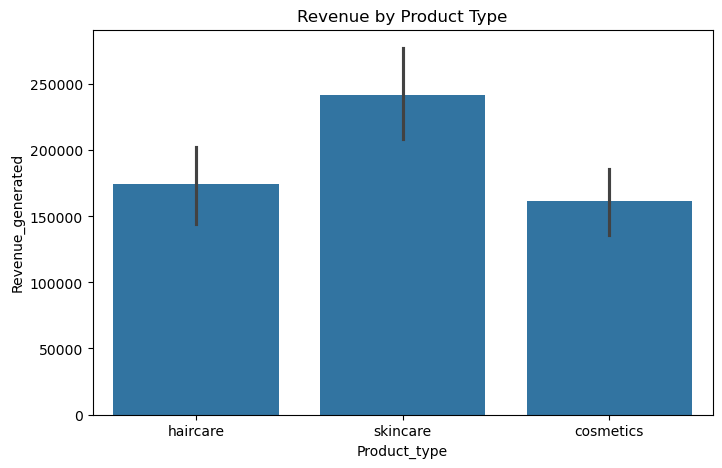

In [26]:
#revenue by product type
plt.figure(figsize=(8,5))

sns.barplot(
x='Product_type',
y='Revenue_generated',
data=df,
estimator=sum
)

plt.title("Revenue by Product Type")
plt.show()

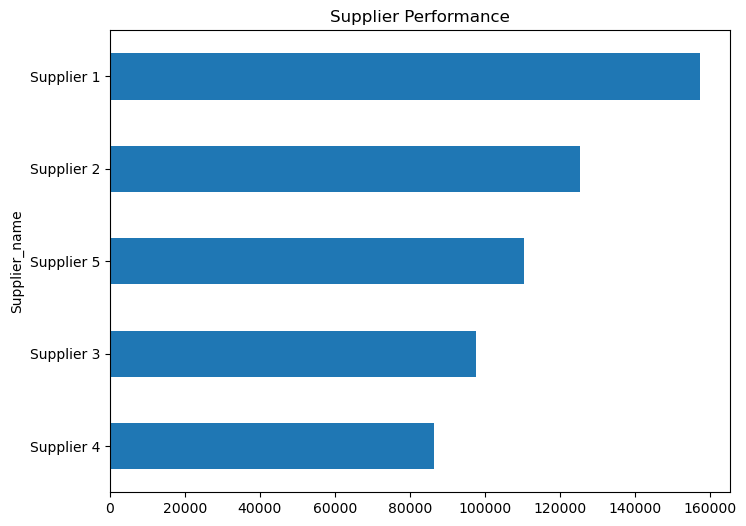

In [29]:
#Supplier Performance
supplier_rev = df.groupby(
'Supplier_name'
)['Revenue_generated'].sum().sort_values()

supplier_rev.plot(
kind='barh',
figsize=(8,6)
)

plt.title("Supplier Performance")
plt.show()

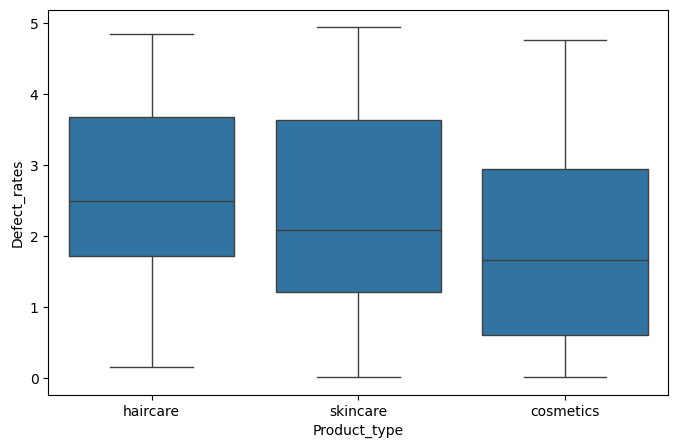

In [30]:
#Defect Rate Analysis
plt.figure(figsize=(8,5))

sns.boxplot(
x='Product_type',
y='Defect_rates',
data=df
)

plt.show()

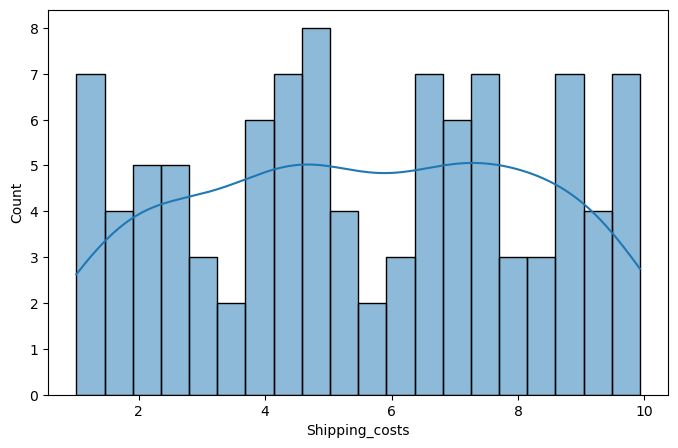

In [32]:
#Shipping Cost Distribution
plt.figure(figsize=(8,5))

sns.histplot(
df['Shipping_costs'],
bins=20,
kde=True
)

plt.show()

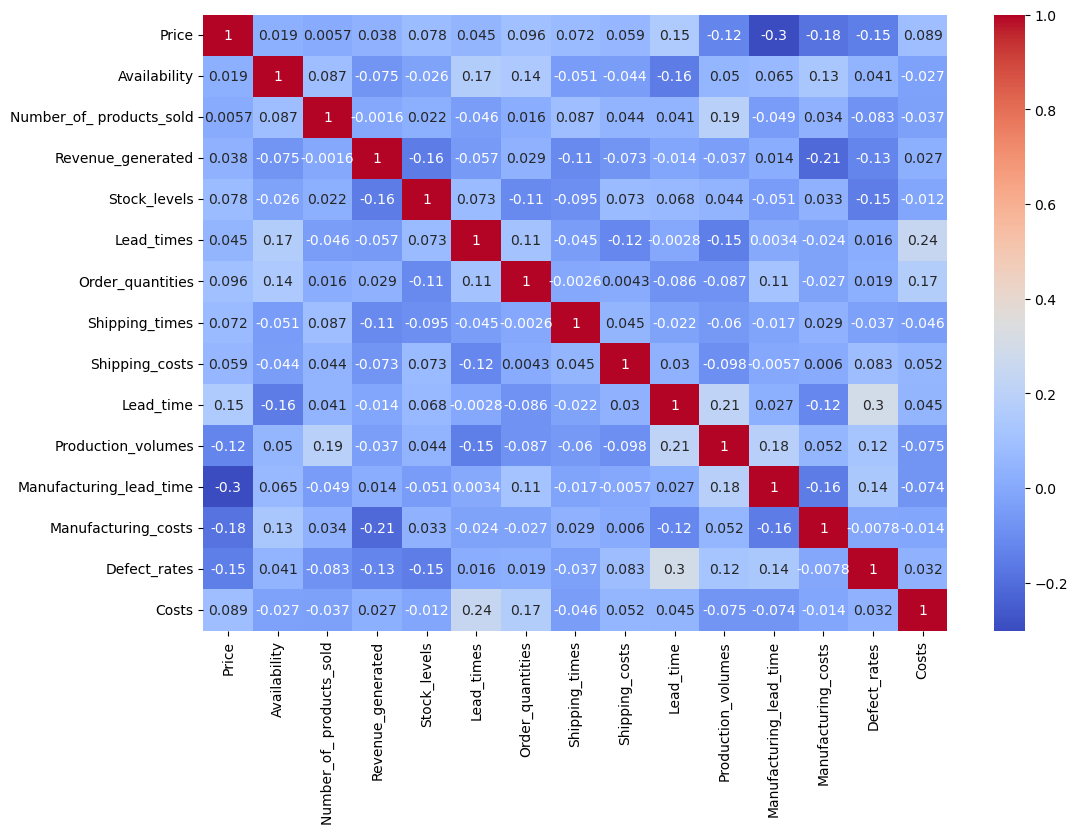

In [33]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
df.corr(numeric_only=True),
annot=True,
cmap='coolwarm'
)

plt.show()

In [36]:
#Create Demand Dataset
demand = df.groupby('SKU')['Number_of_ products_sold'].sum()

In [37]:
#Forecast Using Linear Regression
from sklearn.linear_model import LinearRegression

X = np.arange(len(demand)).reshape(-1,1)

y = demand.values

model = LinearRegression()

model.fit(X,y)

future = np.arange(
len(demand),
len(demand)+12
).reshape(-1,1)

forecast = model.predict(future)

print(forecast)

[447.60484848 447.33979598 447.07474347 446.80969097 446.54463846
 446.27958596 446.01453345 445.74948095 445.48442844 445.21937594
 444.95432343 444.68927093]


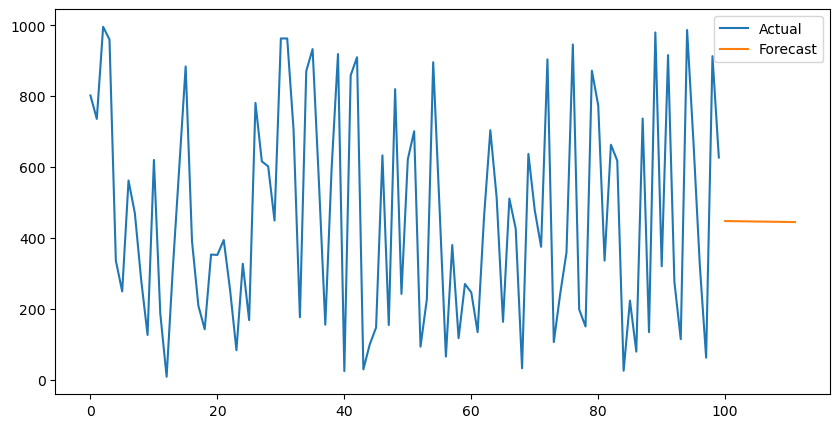

In [38]:
#Forecast Visualization
plt.figure(figsize=(10,5))

plt.plot(y,label='Actual')

plt.plot(
range(len(y),
len(y)+12),
forecast,
label='Forecast'
)

plt.legend()
plt.show()

In [40]:
#Feature Engineering
df['Profit'] = (
df['Revenue_generated']
-
df['Costs']
)

df['Inventory_Status'] = np.where(
df['Stock_levels']<20,
'Low Stock',
'Adequate'
)

df['Delivery_Status'] = np.where(
df['Shipping_times']>7,
'Delayed',
'On Time'
)